## Step-by-Step Guide to Reproducing the Thesis Results

This short tutorial explains how to obtain the five most likely labels for a test image using **Place365 model**.

---

### 1. Download the Required Assets from the repo

| Purpose | File (relative path) |
|---------|----------------------|
| Model | `models/assets/resnet50_places365.pth` |
| Categories (365 scene labels) | `models/assets/categories_places365.txt` |
| Indoor/Outdoor list&nbsp; | `models/assets/IO_places365.txt` |
| Test image *(or use your own)* | `models/assets/Test_Bild.jpg` |

> Once the paths are set correctly, a single script run will output the predictions.

---

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# hier Pfade anpassen 
model_path = r"C:\Users\lpera\OneDrive\Desktop\AirquixAppThesis\models\assets\resnet50_places365.pth"
categories_file = r"C:\Users\lpera\Downloads\categories_places365.txt"
io_file = r"C:\Users\lpera\Downloads\IO_places365.txt"  # das hier sit eine Datei mit Indoor/Outdoor Informationen


img_path = r"C:\Users\lpera\Downloads\Test_Image.jpg"
img = Image.open(img_path).convert("RGB")

# kleine Bildvorverarbeitung
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = preprocess(img).unsqueeze(0)  # Batch-Dim hinzufügen

# Modell laden 
model = models.resnet50(num_classes=365)
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
if "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint
# entferne "module."-Präfix falls nätig
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
model.eval()

# laden der szenenkategorien 
with open(categories_file, "r") as f:
    categories = [line.strip() for line in f.readlines()]

# Indoor/Outdoor-Labels laden
io_labels = []
with open(io_file, "r") as f:
    for line in f:
        parts = line.strip().split()
        try:
            io_labels.append(float(parts[-1]))
        except ValueError as e:
            print(f"Fehler beim Konvertieren der Zeile :( {line}")
            raise e
io_labels = np.array(io_labels)

# Vorhersage Szenenkategorien
logits = model(input_tensor)
probs = F.softmax(logits, dim=1).data.squeeze()
top5 = torch.topk(probs, 5)
top5_probs = top5.values.tolist()
top5_idxs = top5.indices.tolist()

# Bestimme Indoor oder Outdoor 
io_score = np.mean([io_labels[idx] for idx in top5_idxs])
scene_type = "outdoor" if io_score > 0.5 else "indoor"

# Grad-CAM berechnen
# registrier hooks an der letzten cnvolution schicht (bei ResNet50: model.layer4[-1])
features_cam = None
gradients_cam = None

def forward_hook(module, input, output):
    global features_cam
    features_cam = output.detach()

def backward_hook(module, grad_in, grad_out):
    global gradients_cam
    gradients_cam = grad_out[0].detach()

target_layer = model.layer4[-1]
handle_forward = target_layer.register_forward_hook(forward_hook)
handle_backward = target_layer.register_backward_hook(backward_hook)

# vorwärts und backward pass für CAM-Berechnung
logits = model(input_tensor)
pred_probs = F.softmax(logits, dim=1).data.squeeze()
pred_class = pred_probs.argmax().item()
model.zero_grad()
score = logits[0, pred_class]
score.backward()

# Berechne Kanalgewichte
weights_cam = torch.mean(gradients_cam, dim=[1, 2])
cam = torch.zeros(features_cam.shape[2:], dtype=torch.float32)
for i, w in enumerate(weights_cam):
    cam += w * features_cam[0, i, :, :]
cam = F.relu(cam)
cam -= cam.min()
if cam.max() != 0:
    cam /= cam.max()
cam_np = cam.cpu().numpy()
cam_np = cv2.resize(cam_np, (img.width, img.height))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_np), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
img_np = np.array(img)
overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)
# Speichere die CAM als jpg
cv2.imwrite("cam.jpg", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

# Entferne hooks
handle_forward.remove()
handle_backward.remove()

# Ergebnisse zeigen
print("RESULT ON", img_path)
print("--TYPE:", scene_type)
print("--SCENE CATEGORIES:")
for prob, idx in zip(top5_probs, top5_idxs):
    print("{:.3f} -> {}".format(prob, categories[idx]))
print("Class activation map is output as cam.jpg")


Vorhergesagte Klasse: /c/campus 77 (0.109)


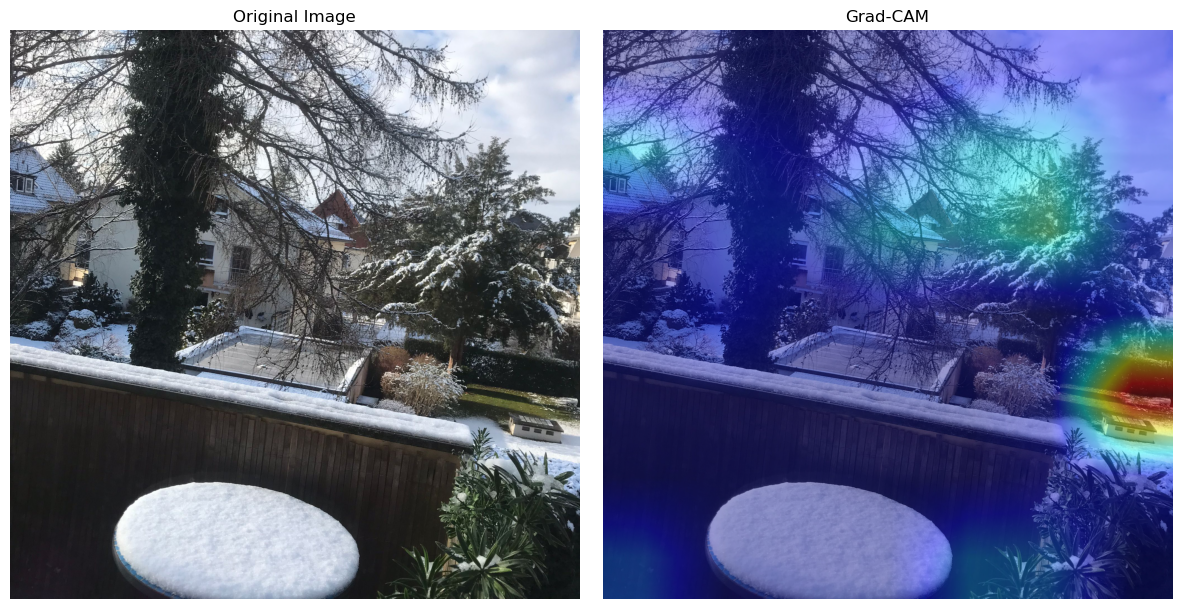

In [10]:
import torch
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2  # wird für die heat map benötigt

# wie immer Pfade anpassen, ganz wichtig 
model_path = r"C:\Users\lpera\OneDrive\Desktop\AirquixAppThesis\models\assets\resnet50_places365.pth"
categories_file = r"C:\Users\lpera\Downloads\categories_places365.txt"
img_path = r"C:\Users\lpera\Downloads\Test_Image.jpg"

# Modell definieren und laden
model = models.resnet50(num_classes=365)
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
if "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

# alles wie vorher
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
model.eval()

with open(categories_file, "r") as f:
    classes = [line.strip() for line in f.readlines()]

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
img = Image.open(img_path).convert("RGB")
input_tensor = preprocess(img).unsqueeze(0)  # Batch-Dimension hinzufügen

# Variablen zum Speichern von features und gradienten 
features = None
gradients = None

# Hook-Funktdefinieren
def forward_hook(module, input, output):
    global features
    features = output.detach()

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()

target_layer = model.layer4[-1]
handle_forward = target_layer.register_forward_hook(forward_hook)
handle_backward = target_layer.register_backward_hook(backward_hook)

# vorwärts pass und vorhersage
output = model(input_tensor)
pred_probs = F.softmax(output, dim=1).squeeze()
pred_class = pred_probs.argmax().item()
print("Vorhergesagte Klasse: {} ({:.3f})".format(classes[pred_class], pred_probs[pred_class].item()))

# backward pass: setze Gradienten für die vorhergesagte klasse 
model.zero_grad()
score = output[0, pred_class]
score.backward()

# Grad-CAM berechnen (berechnet kanalgewichte als globaler Durchschnitt der gradienten über höhe und breite
weights = torch.mean(gradients, dim=[1, 2])  # Shape: [Anzahl Kanäle]

# berechnet die gewichtete Summe der Feature Maps
cam = torch.zeros(features.shape[2:], dtype=torch.float32)  # (H, W)
for i, w in enumerate(weights):
    cam += w * features[0, i, :, :]

# wende ReLU an
cam = F.relu(cam)

# normiere die CAM 
cam -= cam.min()
if cam.max() != 0:
    cam /= cam.max()

# CAM auf original bildgröße skalieren und als Heatmap erzeugen
cam_np = cam.cpu().numpy()
cam_np = cv2.resize(cam_np, (img.width, img.height))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_np), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  

# --- Heatmap als overlay über das originalbild legen
img_np = np.array(img)
overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

# plotten
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

# entfernt hooks
handle_forward.remove()
handle_backward.remove()
